In [1]:
import pandas as pd

file_path = r'D:\Aa中工互联\工作安排\英格索兰\data\预测\每分钟数据.xlsx'
df = pd.read_excel(file_path)

In [2]:
# 定义IQR检测异常值函数
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return (series < lower_bound) | (series > upper_bound)

In [3]:
df.columns

Index(['时间', 'DQ200系统压力', 'AVS系统压力', 'DQ200总流量', 'AVS总流量'], dtype='object')

In [4]:
column = ['DQ200系统压力', 'AVS系统压力', 'DQ200总流量', 'AVS总流量']

In [5]:
import numpy as np

# 对DataFrame中的每一个数值列进行处理
for column in df.select_dtypes(include=[np.number]).columns:
    outliers_mask = detect_outliers_iqr(df[column])
    # 将异常值替换为NaN
    df.loc[outliers_mask, column] = np.nan
    # 使用线性插值填补NaN（包括原始缺失值和被标记的异常值）
    df[column] = df[column].interpolate(method='linear')

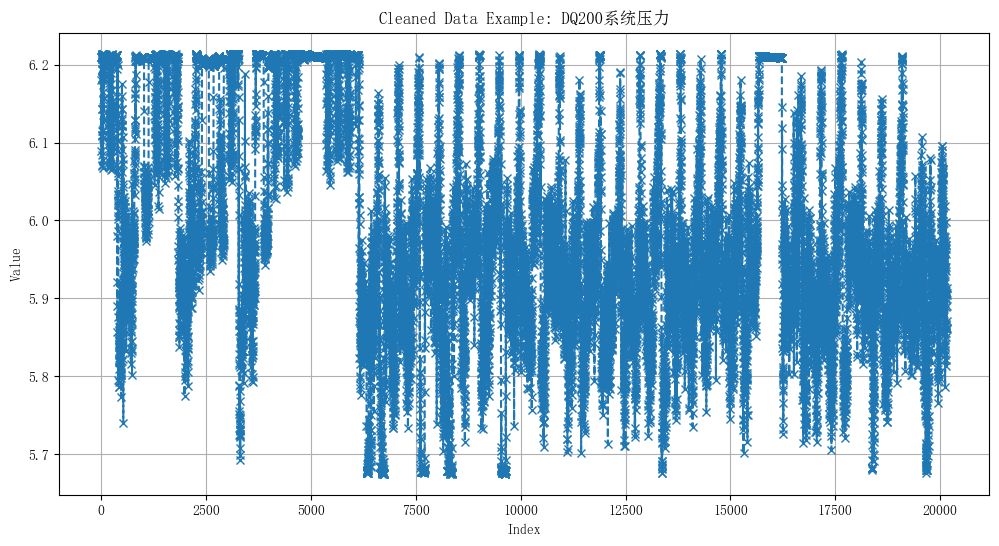

In [6]:
# 可视化对比原数据与清洗后数据（这里只展示一列作为例子）
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['DQ200系统压力'], label='Cleaned Data value1', marker='x', linestyle='--')
plt.title("Cleaned Data Example: DQ200系统压力")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

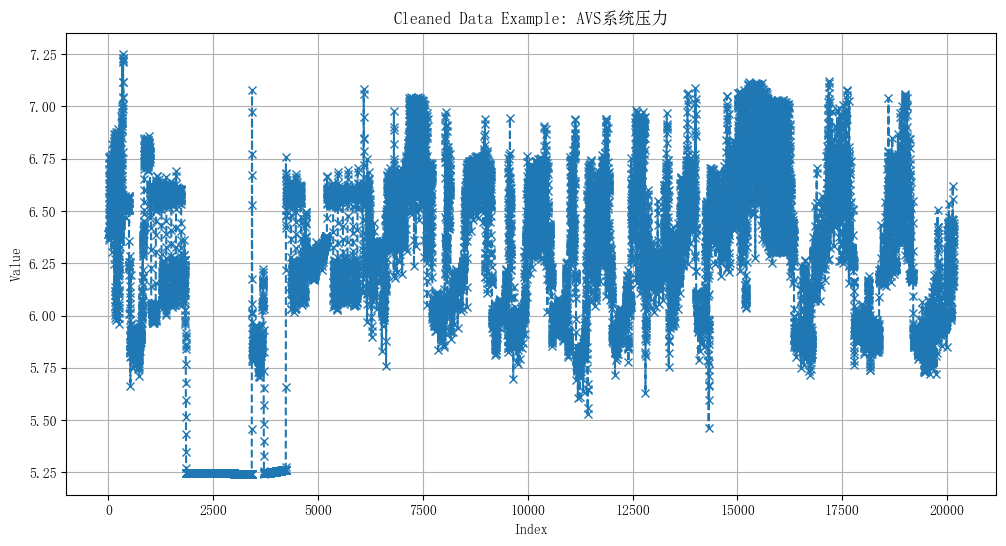

In [7]:
plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['AVS系统压力'], label='Cleaned Data value1', marker='x', linestyle='--')
plt.title("Cleaned Data Example: AVS系统压力")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

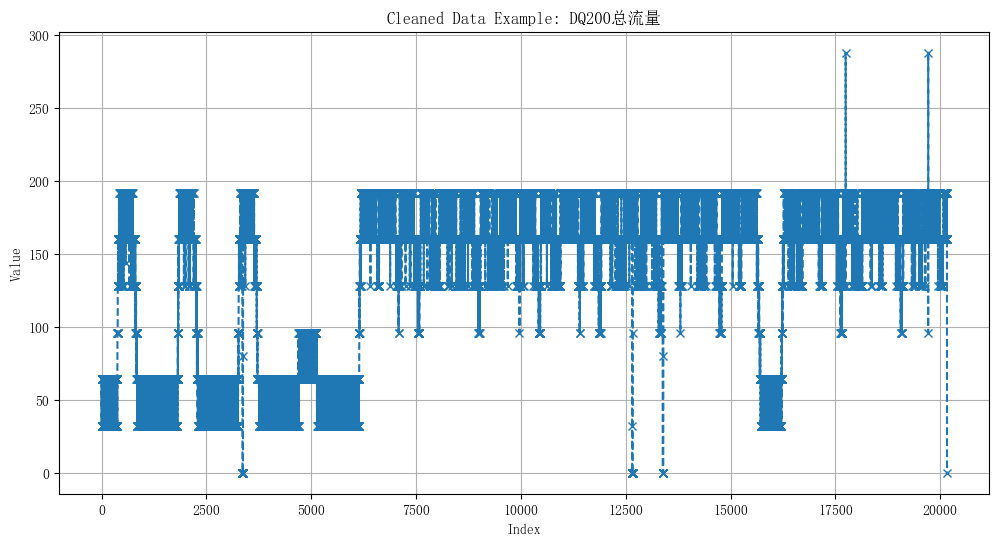

In [8]:
plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['DQ200总流量'], label='Cleaned Data value1', marker='x', linestyle='--')
plt.title("Cleaned Data Example: DQ200总流量")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

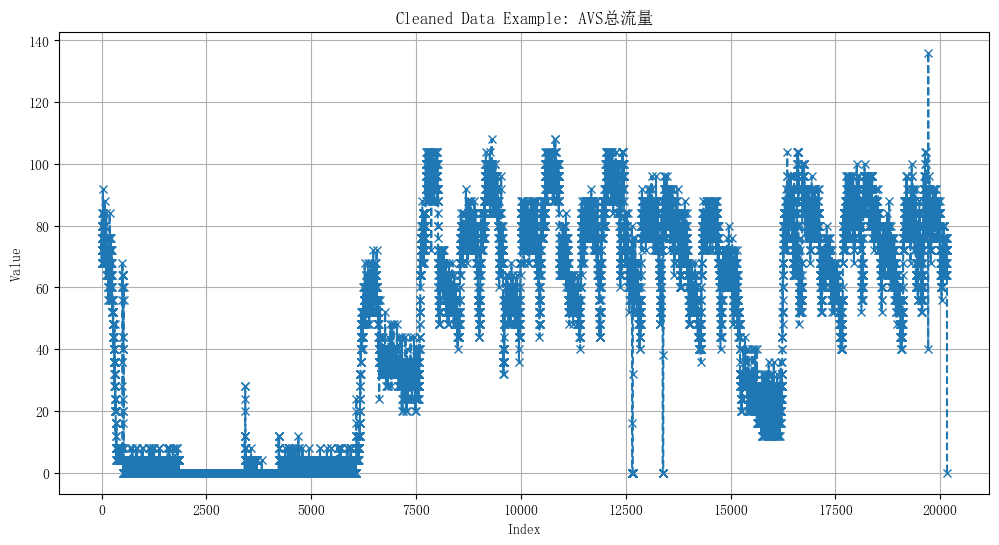

In [9]:
plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['AVS总流量'], label='Cleaned Data value1', marker='x', linestyle='--')
plt.title("Cleaned Data Example: AVS总流量")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [10]:
df.to_excel('分钟数据清洗后.xlsx', index=False)